# [CODE] 2026 LWLR Hackathon 

**제한시간: 60분**

---

---
## 1. 개요 (Introduction) <a id='1-개요'></a>

일반 선형 회귀(OLS)는 전체 데이터를 **하나의 직선**으로 설명하려 하지만, 현실의 데이터는 **비선형적**인 경우가 많습니다.

이번 실습에서는 **서울시 공공자전거(따릉이)** 데이터를 활용하여, 특정 지점 $x_{\text{query}}$ **주변의 데이터에 가중치**를 두어 예측하는 **Locally Weighted Linear Regression(LWLR)** 을 직접 구현합니다.

### 실습 조건
| 항목 | 내용 |
|---|---|
| **허용 라이브러리** | `numpy`, `pandas`, `matplotlib` |
| **금지 라이브러리** | `scikit-learn`, `statsmodels` 등 ML 라이브러리 |
| **데이터** | `Temperature(°C)` → `Rented Bike Count` 예측 (1차원 회귀) |
| **목표** | LWLR 핵심 로직을 **numpy 행렬 연산**으로 구현 |

---
## 2. 수학적 배경 (Mathematical Background) <a id='2-수학적-배경'></a>
아래 서술되는 수학적 배경은 이번 TASK를 풀기 전 짚고 넘어가야할 개념입니다.

### 2.1 OLS vs LWLR

| | OLS (Ordinary Least Squares) | LWLR (Locally Weighted LR) |
|---|---|---|
| **비용 함수** | $J(\theta) = \frac{1}{2}\sum_{i=1}^{m}(\theta^T x^{(i)} - y^{(i)})^2$ | $J(\theta) = \frac{1}{2}\sum_{i=1}^{m} w^{(i)}(\theta^T x^{(i)} - y^{(i)})^2$ |
| **특징** | 모든 데이터 포인트에 동일한 가중치 | 예측 지점에 가까운 데이터에 높은 가중치 |
| **모델 유형** | Parametric (학습 후 데이터 불필요) | Non-parametric (예측 시마다 전체 데이터 필요) |  
  
*여기서 OLS는 선형회귀를 말합니다.

### 2.2 가중치 함수 (Weight Function)

가중치 $w^{(i)}$는 다음과 같은 **가중치 함수**로 정의됩니다:

$$w^{(i)} = \exp\left(-\frac{\|x^{(i)} - x_{\text{query}}\|_2^2}{2\tau^2}\right)$$

- $x_{\text{query}}$: 예측하려는 지점
- $x^{(i)}$: $i$번째 학습 데이터
- $\tau$ (tau): **대역폭(bandwidth)** 하이퍼파라미터
  - $\tau$가 **작으면** → 가까운 데이터만 영향 → **과적합(overfitting)** 경향
  - $\tau$가 **크면** → 먼 데이터도 영향 → **과소적합(underfitting)** 경향

### 2.3 정규 방정식 (Normal Equation)

비용 함수를 $\theta$에 대해 미분하여 0으로 놓으면, 최적해를 **닫힌 형태(Closed-form)**로 구할 수 있습니다:

$$\theta = (X^T \cdot W \cdot X)^{-1} \cdot X^T \cdot W \cdot y$$

여기서 $W$는 $w^{(i)}$를 대각 성분으로 갖는 $m \times m$ 대각 행렬입니다.

> 이 정규 방정식은 OLS의 정규 방정식 $\theta = (X^T X)^{-1} X^T y$ 에서, **가중치 행렬 $W$가 추가된 형태**입니다.  
> LWLR에서는 예측하려는 지점마다 $W$가 달라지므로, 매번 새로운 $\theta$를 계산해야 합니다.

---

### [Task 1] 가중치 함수 구현 (10점)

위 수식(2.2)을 참고하여, 예측 지점 `x_query`에 대한 **각 학습 데이터의 가중치를 계산하는 함수**를 구현하세요.

**구현 요구사항:**
1. 각 학습 데이터 $x^{(i)}$와 예측 지점 $x_{\text{query}}$ 사이의 **거리의 제곱** (`diff_sq`)을 계산
2. 위 가중치 함수 수식을 적용하여 **가중치 벡터** `weights`를 계산
3. 가중치 벡터를 **대각 행렬** `W`로 변환하여 반환

> **유용한 numpy 함수**: `np.sum()`, `np.exp()`, `np.diag()`
> 
> **핵심 아이디어**: `X - x_query`를 하면 모든 데이터와 query 사이의 차이를 한 번에 계산할 수 있습니다

In [2]:
import numpy as np
def compute_weights(x_query, X, tau):
    """
    가중치 함수를 사용하여 가중치 대각 행렬 W를 계산합니다.
    
    Parameters
    ----------
    x_query : np.ndarray, shape (n,)
        예측하고자 하는 지점 (예: [1, 25.0])
    X : np.ndarray, shape (m, n)
        학습 데이터 피처 행렬
    tau : float
        대역폭(bandwidth) 하이퍼파라미터
    
    Returns
    -------
    W : np.ndarray, shape (m, m)
        가중치 대각 행렬
    """
    x_query = np.array(x_query).flatten()  # (n,) 형태로 통일
    
    # =============================================
    # Step 1: 각 데이터와 query 사이의 거리 제곱 계산
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1줄) 🔽🔽🔽
    diff_sq =np.sum((X - x_query) ** 2, axis=1)
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    
    # =============================================
    # Step 2: 가중치 벡터 계산
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1줄) 🔽🔽🔽
    weights = np.exp(-diff_sq / (2 * tau ** 2))
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    
    # =============================================
    # Step 3: 가중치 대각 행렬 W 구성
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1줄) 🔽🔽🔽
    W = np.diag(weights)
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    
    return W

In [3]:
# ========================================
# Task 1 검증 (Sanity Check)
# ========================================
# 아래 셀은 데이터 준비 이후에 실행하세요.
# 간단한 테스트로 함수가 올바르게 작동하는지 확인합니다.

# 작은 테스트 데이터로 검증
X_test = np.array([[1, 0], [1, 1], [1, 2], [1, 3]])  # 4개 데이터
x_q_test = np.array([1, 1.5])  # query point
tau_test = 1.0

try:
    W_test = compute_weights(x_q_test, X_test, tau_test)
    print(f'   함수 실행 성공!')
    print(f'   W 행렬 크기: {W_test.shape}  (기대값: (4, 4))')
    print(f'   W 대각 성분: {np.diag(W_test).round(4)}')
    print(f'   → query(1.5)에서 가장 가까운 데이터(1, 2)의 가중치가 가장 커야 합니다')
    diag = np.diag(W_test)
    if diag[1] > diag[0] and diag[2] > diag[3] and W_test.shape == (4,4):
        print(f'    가중치 패턴이 올바릅니다!')
    else:
        print(f'    가중치 패턴을 다시 확인하세요.')
except Exception as e:
    print(f' 오류 발생: {e}')
    print(f'   코드를 다시 확인하세요!')

   함수 실행 성공!
   W 행렬 크기: (4, 4)  (기대값: (4, 4))
   W 대각 성분: [0.3247 0.8825 0.8825 0.3247]
   → query(1.5)에서 가장 가까운 데이터(1, 2)의 가중치가 가장 커야 합니다
    가중치 패턴이 올바릅니다!


---
## 3. 데이터 탐색 (EDA) - 수정 금지, 순차적으로 코드 셀 실행 <a id='3-데이터-탐색'></a>

먼저 데이터를 로드하고 기본적인 탐색을 수행합니다.

In [4]:
# ========================================
# 라이브러리 임포트 (수정 금지)
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정 (Windows)
matplotlib.rcParams['axes.unicode_minus'] = False

print(" 라이브러리 로드 완료!")
print(f"   numpy: {np.__version__}")
print(f"   pandas: {pd.__version__}")

 라이브러리 로드 완료!
   numpy: 1.26.4
   pandas: 2.1.4


In [5]:
# ========================================
# 데이터 로드
# ========================================
df = pd.read_csv('C:/Users/user/Desktop/SeoulBikeData.csv', encoding='unicode_escape')

print(f"데이터 크기: {df.shape}")
print(f"컬럼 목록:")
for i, col in enumerate(df.columns):
    print(f"   [{i:2d}] {col}")
print()
df.head()

데이터 크기: (8760, 14)
컬럼 목록:
   [ 0] Date
   [ 1] Rented Bike Count
   [ 2] Hour
   [ 3] Temperature(°C)
   [ 4] Humidity(%)
   [ 5] Wind speed (m/s)
   [ 6] Visibility (10m)
   [ 7] Dew point temperature(°C)
   [ 8] Solar Radiation (MJ/m2)
   [ 9] Rainfall(mm)
   [10] Snowfall (cm)
   [11] Seasons
   [12] Holiday
   [13] Functioning Day



,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
# ========================================
# 피처 / 타겟 추출 및 전처리
# ========================================
# 컬럼명 정리 (인코딩 문제 방지)
temp_col = [c for c in df.columns if 'Temperature' in c][0]
target_col = 'Rented Bike Count'

# Functioning Day == 'Yes' 인 데이터만 사용
df_clean = df[df['Functioning Day'] == 'Yes'].copy()
print(f" 유효 데이터: {len(df_clean)}건 (원본 {len(df)}건 중 Functioning Day='Yes')")

# numpy 배열로 변환
temp = df_clean[temp_col].values.astype(float)   # 기온
count = df_clean[target_col].values.astype(float) # 대여 건수

print(f"    기온 범위: {temp.min():.1f}°C ~ {temp.max():.1f}°C")
print(f"    대여량 범위: {count.min():.0f} ~ {count.max():.0f}")

 유효 데이터: 8465건 (원본 8760건 중 Functioning Day='Yes')
    기온 범위: -17.8°C ~ 39.4°C
    대여량 범위: 2 ~ 3556


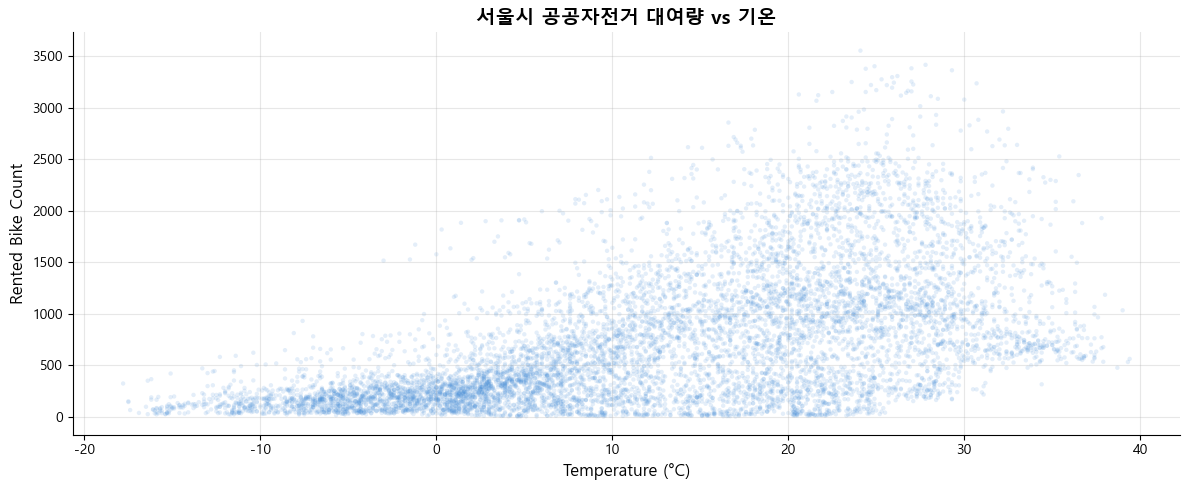

In [7]:
# ========================================
# 산점도로 데이터 분포 확인
# ========================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(temp, count, alpha=0.15, s=10, c='#4A90D9', edgecolors='none')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Rented Bike Count', fontsize=12)
ax.set_title('서울시 공공자전거 대여량 vs 기온', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


(시각화해보니 어떤가요? 특징을 서술해주세요.)
따릉이를 탈 경우 바람이 많이 불기 때문에 기온보다 체감온도가 더 낮을 것이다. 따라서 더운 날씨나, 따뜻한 날씨가 추운날씨나 시원한 날씨보다 대여량이 더 많은 모습으로 보인다.

In [8]:
# ========================================
# 학습 데이터 행렬 구성 (수정 금지)
# ========================================
# X: (m, 2) → [1, temp] (절편 포함)
# y: (m, 1)
m = len(temp)
X = np.column_stack([np.ones(m), temp])  # (m, 2) - bias term 추가
y = count.reshape(-1, 1)                  # (m, 1)

print(f"   학습 데이터 준비 완료")
print(f"   X shape: {X.shape}  (m={m}, n=2: [bias, temp])")
print(f"   y shape: {y.shape}")
print(f"   X 샘플:\n{X[:3]}")

   학습 데이터 준비 완료
   X shape: (8465, 2)  (m=8465, n=2: [bias, temp])
   y shape: (8465, 1)
   X 샘플:
[[ 1.  -5.2]
 [ 1.  -5.5]
 [ 1.  -6. ]]


---
## 4. 구현 (Implementation) <a id='4-구현'></a>

### 4.1 데이터 준비

###  **[Task 2] LWLR 예측 함수 구현 (40점)**

Task 1에서 만든 `compute_weights()` 함수를 활용하여, LWLR 예측 함수를 완성하세요.

**구현 단계:**
1. **가중치 행렬 계산**: Task 1의 `compute_weights()` 함수를 호출
2. **정규 방정식 적용**: $\theta = (X^T W X)^{-1} X^T W y$
3. **예측값 반환**: $\hat{y} = x_{\text{query}} \cdot \theta$

>  **유용한 numpy 함수**: `np.linalg.inv()`, `@` (행렬 곱)
> 
>  **핵심**: 가중치 계산은 이미 Task 1에서 구현했으므로, 여기서는 정규 방정식의 코드 구현에 집중하세요

In [9]:
def lwlr(x_query, X, y, tau):
    """
    Locally Weighted Linear Regression (LWLR)
    
    Parameters
    ----------
    x_query : np.ndarray, shape (n,) 또는 (1, n)
        예측하고자 하는 지점 (예: [1, 25.0])
    X : np.ndarray, shape (m, n)
        학습 데이터 피처 행렬
    y : np.ndarray, shape (m, 1)
        학습 데이터 타겟 벡터
    tau : float
        대역폭(bandwidth) 하이퍼파라미터
    
    Returns
    -------
    float : 예측값 y_hat
    """
    x_query = np.array(x_query).flatten()  # (n,) 형태로 통일
    
    # =============================================
    # Step 1: 가중치 행렬 W 계산
    #   Task 1에서 구현한 compute_weights() 함수를 호출
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1줄) 🔽🔽🔽
    W = compute_weights(x_query, X, tau)
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    
    # =============================================
    # Step 2: 정규 방정식으로 theta 계산
    #   theta = (X^T W X)^(-1) X^T W y
    #   힌트: np.linalg.inv()와 @ 연산자를 사용
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1~2줄) 🔽🔽🔽
    inv_part = np.linalg.inv(X.T @ W @ X)
    theta = inv_part @ X.T @ W @ y
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    
    # =============================================
    # Step 3: 예측값 반환
    # =============================================
    # 🔽🔽🔽 여기에 코드를 작성하세요 (약 1줄) 🔽🔽🔽
    y_hat = x_query @ theta
    
    # 🔼🔼🔼 코드 작성 끝 🔼🔼🔼
    return float(y_hat)

In [10]:
# ========================================
#  구현 검증 (Sanity Check)
# ========================================
# 기온 20°C일 때의 예측값을 테스트합니다.
test_query = np.array([1, 20.0])  # [bias, temperature]
test_tau = 5.0

try:
    test_pred = lwlr(test_query, X, y, test_tau)
    print(f" 함수 실행 성공!")
    print(f"   기온 20°C 예측 대여량: {test_pred:.1f}대")
    
    # 합리적인 범위 체크
    if 400 < test_pred < 1500:
        print(f"   예측값이 합리적인 범위 내에 있습니다!")
    else:
        print(f"   예측값이 예상 범위를 벗어났습니다. 코드를 다시 확인하세요.")
except Exception as e:
    print(f" 오류 발생: {e}")
    print(f"   코드를 다시 확인하세요!")

 함수 실행 성공!
   기온 20°C 예측 대여량: 999.3대
   예측값이 합리적인 범위 내에 있습니다!


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27348\2677044421.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(y_hat)


---
## 5. 시각화 및 분석 (Visualization & Analysis) <a id='5-시각화-및-분석'></a>

###  **[Task 3] 전체 예측 곡선 생성 (20점)**

구현한 `lwlr()` 함수를 사용하여, 다양한 기온에서의 예측값을 계산하고 시각화하세요.

**요구사항:**
1. 기온 범위 `-17°C ~ 39°C`에서 100개의 query point를 생성 (`np.linspace` 사용)
2. 각 query point에 대해 `lwlr()` 호출하여 예측값 계산
3. `tau = 3` 으로 설정

In [11]:
# ========================================
# [Task 3] 전체 예측 곡선 생성
# ========================================
tau = 3.0

# 🔽🔽🔽 여기에 코드를 작성하세요 🔽🔽🔽
# 1) x_range: -17 ~ 39 사이 100개의 query point 생성
x_range = np.linspace(-17, 39, 100)

# 2) predictions: 각 query point에 대한 LWLR 예측값 리스트
#    (힌트: for 루프로 각 query point에 대해 lwlr() 호출)
# 고수의 1줄 요약 버전
predictions = [lwlr([1, temp], X, y, tau) for temp in x_range]

# 🔼🔼🔼 코드 작성 끝 🔼🔼🔼

print(f" {len(x_range)}개 지점에 대한 예측 완료!")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27348\2677044421.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(y_hat)


 100개 지점에 대한 예측 완료!


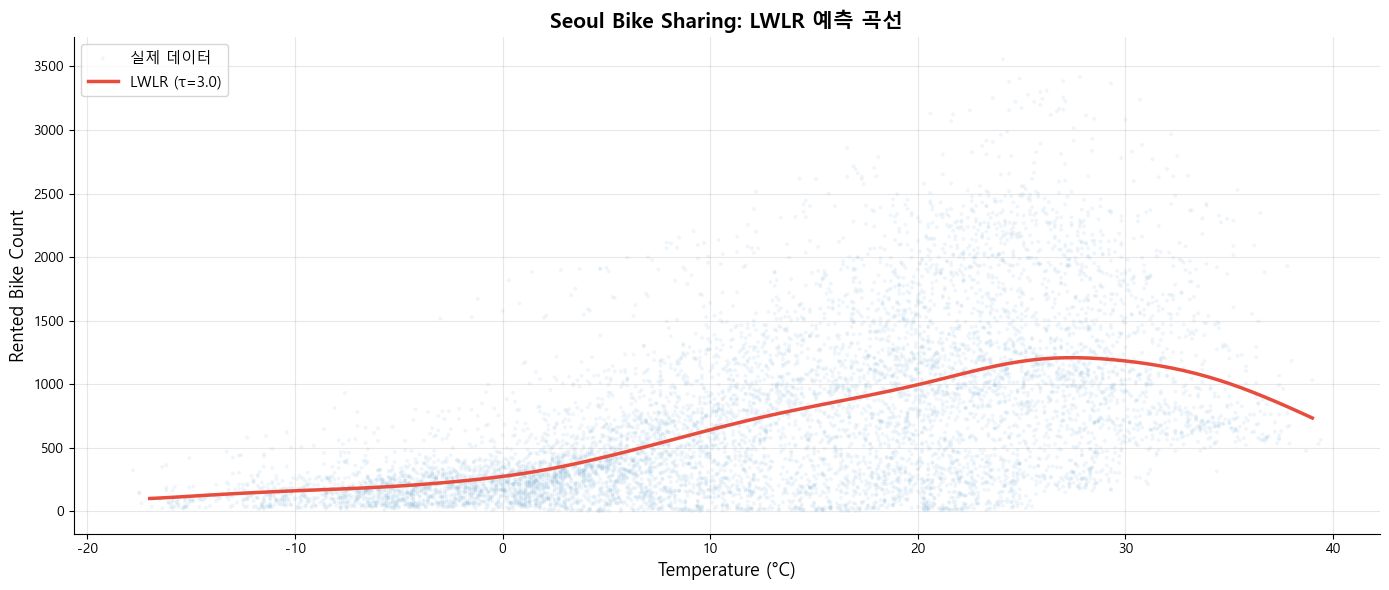

In [12]:
# ========================================
# 시각화 (수정 금지)
# ========================================
fig, ax = plt.subplots(figsize=(14, 6))

# 원본 데이터 산점도
ax.scatter(temp, count, alpha=0.12, s=8, c='#7FB3D8', edgecolors='none', label='실제 데이터')

# LWLR 예측 곡선
ax.plot(x_range, predictions, color='#E74C3C', linewidth=2.5, label=f'LWLR (τ={tau})', zorder=5)

ax.set_xlabel('Temperature (°C)', fontsize=13)
ax.set_ylabel('Rented Bike Count', fontsize=13)
ax.set_title('Seoul Bike Sharing: LWLR 예측 곡선', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

###  **[Task 4] τ(tau)에 따른 예측 변화 비교 (20점)**

서로 다른 $\tau$ 값 (`0.5`, `3`, `10`, `50`)에 대해 LWLR 예측 곡선을 **하나의 그래프**에 그려 비교하세요.

**요구사항:**
1. 4개의 $\tau$ 값에 대해 각각 예측 곡선 생성
2. 하나의 그래프에 모든 곡선을 겹쳐서 시각화
3. 범례(legend)에 각 $\tau$ 값 표시
4. 각 $\tau$에 대한 **관찰 결과**를 마크다운으로 작성

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27348\2677044421.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(y_hat)


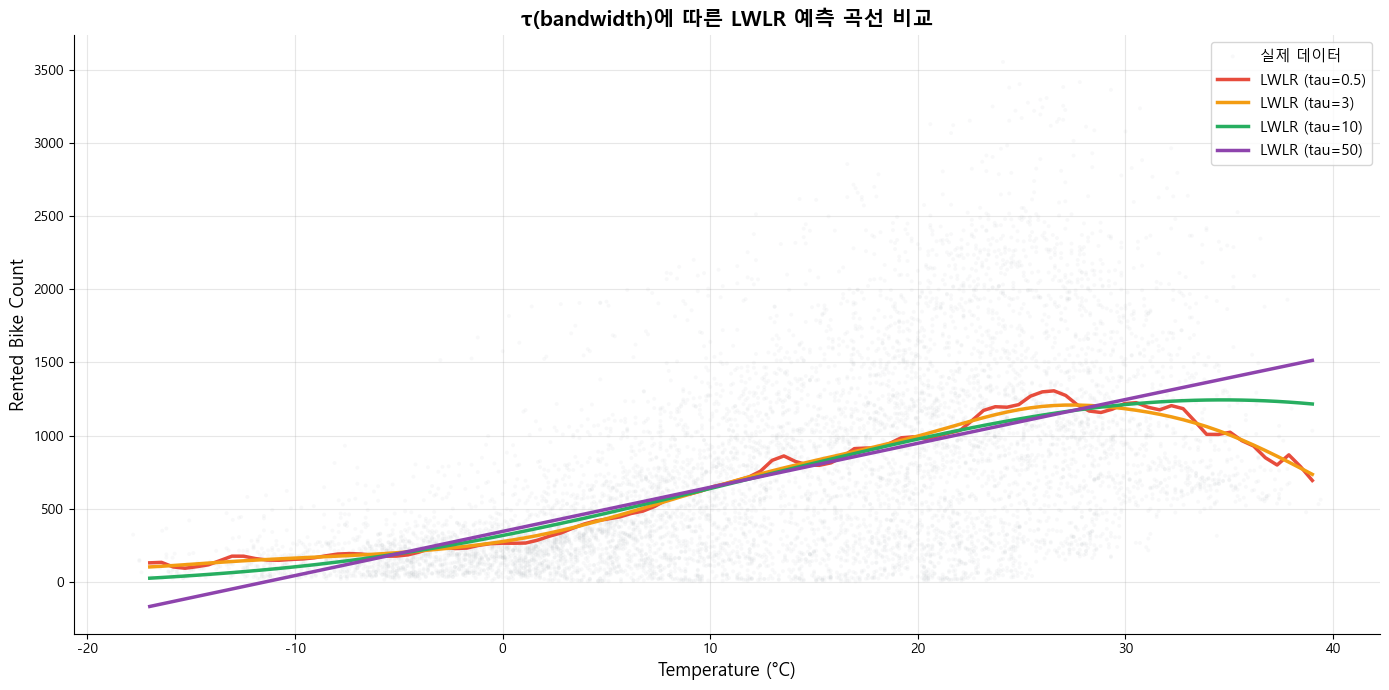

In [13]:
# ========================================
# [Task 4] τ에 따른 비교
# ========================================
tau_list = [0.5, 3, 10, 50]
colors = ['#E74C3C', '#F39C12', '#27AE60', '#8E44AD']  # 빨강, 주황, 초록, 보라

fig, ax = plt.subplots(figsize=(14, 7))

# 원본 데이터
ax.scatter(temp, count, alpha=0.10, s=8, c='#BDC3C7', edgecolors='none', label='실제 데이터')

# 🔽🔽🔽 여기에 코드를 작성하세요 🔽🔽🔽
# 각 tau 값에 대해 예측 곡선을 계산하고 그래프에 추가하세요
# (힌트: for 루프를 사용하여 tau_list와 colors를 순회, ax.plot() 함수 사용)
for t, color in zip(tau_list, colors):
    # 1) x_range의 각 온도에 대해 예측값 리스트 생성 (Task 3과 동일)
    predictions = [lwlr([1, temp_val], X, y, t) for temp_val in x_range]
    
    # 2) 계산된 예측값으로 부드러운 선 그래프 그리기
    ax.plot(x_range, predictions, color=color, linewidth=2.5, label=f'LWLR (tau={t})')





# 🔼🔼🔼 코드 작성 끝 🔼🔼🔼

ax.set_xlabel('Temperature (°C)', fontsize=13)
ax.set_ylabel('Rented Bike Count', fontsize=13)
ax.set_title('τ(bandwidth)에 따른 LWLR 예측 곡선 비교', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

###  [Task 4 서술] τ 값에 따른 관찰 결과

아래 표를 완성하세요:

| τ 값 | 곡선의 특징 | 과적합/과소적합 여부 |
|---|---|---|
| 0.5 | [울긋불긋 너무 예민하다] | [과대적합] |
| 3 | [제가 생각하는 딱 맞는 곡선] | [적합] |
| 10 | [꺾이는 지점이 있으나 약하다] | [과소적합] |
| 50 | [선형의 형태를 띤다] | [과소적합] |

---
## 6. 보너스 챌린지 (Bonus Challenge) <a id='6-보너스-챌린지'></a>

###  **[Bonus Task] MSE 기반 최적 τ 탐색 (10점)**

다양한 $\tau$ 값에 대해 **MSE(Mean Squared Error)**를 계산하고, 최적의 $\tau$를 찾으세요.

**조건:**
- $\tau$ 후보: `[0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]`
- 계산 효율을 위해 **전체 데이터에서 200개를 균일하게 샘플링**하여 MSE 계산
- MSE 공식: $\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

In [14]:
# ========================================
# [Bonus] 최적 τ 탐색
# ========================================
tau_candidates = [0.5, 1, 2, 3, 5, 7]

# 계산 효율을 위한 서브샘플링
np.random.seed(2026)
sample_idx = np.random.choice(m, size=min(200, m), replace=False)
X_sample = X[sample_idx]
y_sample = y[sample_idx]

print(f"📊 평가 샘플: {len(X_sample)}개")
print(f"📊 τ 후보: {tau_candidates}")
print(f"⏳ 계산 중... (약 2~3분 소요)\n")

# 🔽🔽🔽 여기에 코드를 작성하세요 🔽🔽🔽
# 각 tau에 대해 MSE를 계산하세요
# mse_results: {tau: mse_value} 딕셔너리

mse_results = {}

for t in tau_candidates:
    predictions = []
    
    # 1. 200개의 샘플 데이터 각각에 대해 예측을 수행합니다
    for x_query in X_sample:
        # 학습은 전체 데이터(X, y)로 하되, 예측은 샘플(x_query)에 대해서만 진행
        y_hat = lwlr(x_query, X, y, t)
        predictions.append(y_hat)
        
    # 2. 리스트를 넘파이 배열로 변환하고 실제 정답과 형태(shape) 맞추기
    predictions = np.array(predictions)
    actuals = y_sample.flatten()  # (200, 1) 형태를 (200,)으로 납작하게 폅니다
    
    # 3. MSE(Mean Squared Error) 공식 적용: (정답 - 예측값) 제곱의 평균
    mse = np.mean((actuals - predictions) ** 2)
    
    # 4. 딕셔너리에 결과 저장
    mse_results[t] = mse
    
    # (선택) 너무 오래 걸리니 심심하지 않게 진행 상황을 출력해 줍니다
    print(f"  [진행중] τ = {t:4.1f} 완료!")

# 🔼🔼🔼 코드 작성 끝 🔼🔼🔼

# 결과 출력
print("\n τ별 MSE 결과:")
print("-" * 30)
for tau_val, mse_val in mse_results.items():
    print(f"   τ = {tau_val:5.1f}  →  MSE = {mse_val:,.0f}")

best_tau = min(mse_results, key=mse_results.get)
print(f"\n 최적 τ = {best_tau} (MSE = {mse_results[best_tau]:,.0f})")

📊 평가 샘플: 200개
📊 τ 후보: [0.5, 1, 2, 3, 5, 7]
⏳ 계산 중... (약 2~3분 소요)



C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27348\2677044421.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(y_hat)


  [진행중] τ =  0.5 완료!
  [진행중] τ =  1.0 완료!
  [진행중] τ =  2.0 완료!
  [진행중] τ =  3.0 완료!
  [진행중] τ =  5.0 완료!
  [진행중] τ =  7.0 완료!

 τ별 MSE 결과:
------------------------------
   τ =   0.5  →  MSE = 245,728
   τ =   1.0  →  MSE = 246,214
   τ =   2.0  →  MSE = 245,305
   τ =   3.0  →  MSE = 244,872
   τ =   5.0  →  MSE = 244,778
   τ =   7.0  →  MSE = 245,549

 최적 τ = 5 (MSE = 244,778)


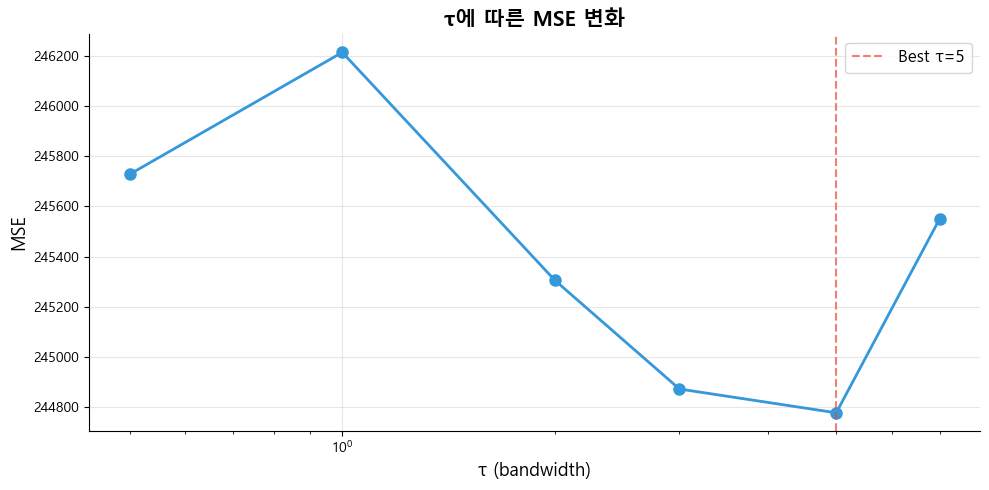

In [16]:
# ========================================
# MSE 그래프 (수정 금지) — Bonus Task 완료 후 실행
# ========================================
fig, ax = plt.subplots(figsize=(10, 5))
taus = list(mse_results.keys())
mses = list(mse_results.values())

ax.plot(taus, mses, 'o-', color='#3498DB', linewidth=2, markersize=8)
ax.axvline(x=best_tau, color='#E74C3C', linestyle='--', alpha=0.7, label=f'Best τ={best_tau}')
ax.set_xlabel('τ (bandwidth)', fontsize=13)
ax.set_ylabel('MSE', fontsize=13)
ax.set_title('τ에 따른 MSE 변화', fontsize=15, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---


---
**파일 제출 형식은  `.ipynb` 입니다. 팀별 최종 결과물을 학회장 '김한세'에게 개인톡으로 전달주시면 됩니다.**

모두 수고하셨습니다~😊